In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from fractal_textures import fgn2D, mask_ellipse, mask_ellipse_PIECES, mask_rectangle, fgn2D_piecewise

Requires the PyAFBF toolbox https://fjprichard.github.io/PyAFBF/

From PyPI
> pip install PyAFBF

#### 1. HOMOGENEOUS ISOTROPIC FRACTAL TEXTURES 

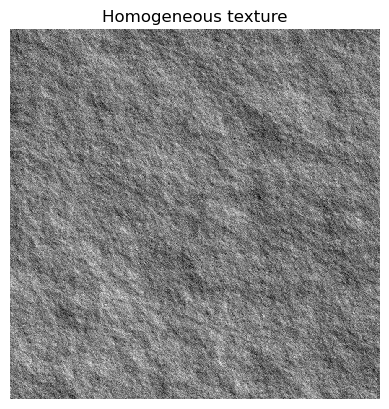

In [4]:
# Image of size 2^N X 2^N
N   = 9;

# Local regularity, a.k.a Hurst exponent 
H   = 0.75;

# Local variance
Var = 1;

# Generate an homogeneous texture
HOM = fgn2D(N,H,Var);

# Display the texture
fig, ax = plt.subplots()
ax.pcolormesh(HOM,cmap='gray')
ax.axis('off');
ax.set_title('Homogeneous texture')
ax.set_box_aspect(1)

#### 2. PIECEWISE HOMOGENEOUS FRACTAL TEXTURE

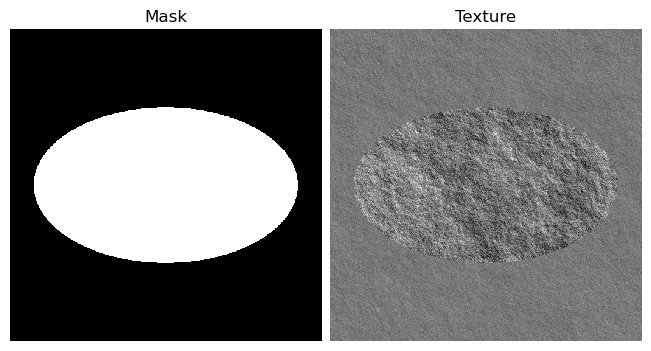

In [6]:
# Image of size 2^N X 2^N
N = 9;

# Local regularities H
H1 = 0.5; H2 = 0.75;

# Local variances 
Var1 = 1; Var2 = 10;

# Choose among the three masks
[H, Var, MASK] = mask_ellipse(N,H1,H2,Var1,Var2);         # one central ellipse
# [H, Var, MASK] = mask_ellipse_PIECES(N,H1,H2,Var1,Var2);  # four ellipses
# [H, Var, MASK] = mask_rectangle(N,H1,H2,Var1,Var2);       # central rectangle

# Piecewise monofractal
X = fgn2D_piecewise(N,H1,H2,Var1,Var2,MASK);

# Display the mask and the texture
fig, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained")

ax1.pcolormesh(MASK,cmap='gray')
ax1.axis('off');
ax1.set_title('Mask')
ax1.set_box_aspect(1)

ax2.pcolormesh(X,cmap='gray')
ax2.axis('off');
ax2.set_title('Texture')
ax2.set_box_aspect(1)

In [7]:
from_Matlab = loadmat('from_Matlab.mat',squeeze_me=True)

#### 3. MULTI-SCALE ANALYSIS - LEADERS COEFFICIENTS

In [9]:
h_LR = from_Matlab["h_LR"]
seg_LR = from_Matlab["seg_LR"]
perf_LR = from_Matlab["perf_LR"]

#### 4. ROF FUNCTIONAL WITH MANUAL CHOICE OF REGULARIZATION PARAMETER

In [11]:
h_rof_man = from_Matlab["h_rof_man"]
seg_rof_man = from_Matlab["seg_rof_man"]
perf_rof_man = from_Matlab["perf_rof_man"]

h_rof_med = from_Matlab["h_rof_med"]
seg_rof_med = from_Matlab["seg_rof_med"]
perf_rof_med = from_Matlab["perf_rof_med"]

h_rof_hig = from_Matlab["h_rof_hig"]
seg_rof_hig = from_Matlab["seg_rof_hig"]
perf_rof_hig = from_Matlab["perf_rof_hig"]

#### 5. BFGS MINIMIZATION USING SUGAR -- ROF FUNCTIONAL

In [13]:
h_rof_opt = from_Matlab["h_rof_opt"]
seg_rof_opt = from_Matlab["seg_rof_opt"]
perf_rof = from_Matlab["perf_rof"]

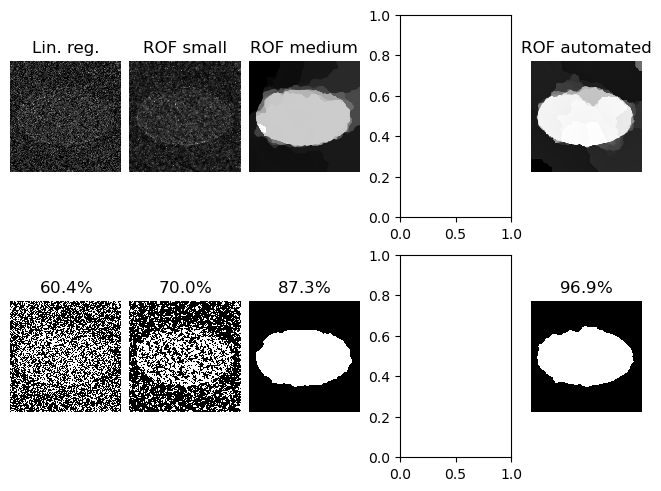

In [33]:
# Display the linear regression, manual ROF and automated ROF estimates
fig, ax = plt.subplots(ncols=5, nrows=2, layout="constrained")

ax[0,0].pcolormesh(h_LR,cmap='gray')
ax[0,0].axis('off');
ax[0,0].set_title('Lin. reg.')
ax[0,0].set_box_aspect(1)
ax[1,0].pcolormesh(seg_LR,cmap='gray')
ax[1,0].axis('off');
ax[1,0].set_title("$" + "{:.1f}".format(100*perf_LR) + "$%")
ax[1,0].set_box_aspect(1)

ax[0,1].pcolormesh(h_rof_man,cmap='gray')
ax[0,1].axis('off');
ax[0,1].set_title('ROF small')
ax[0,1].set_box_aspect(1)
ax[1,1].pcolormesh(seg_rof_man,cmap='gray')
ax[1,1].axis('off');
ax[1,1].set_title("$" + "{:.1f}".format(100*perf_rof_man) + "$%")
ax[1,1].set_box_aspect(1)

ax[0,2].pcolormesh(h_rof_med,cmap='gray')
ax[0,2].axis('off');
ax[0,2].set_title('ROF medium')
ax[0,2].set_box_aspect(1)
ax[1,2].pcolormesh(seg_rof_med,cmap='gray')
ax[1,2].axis('off');
ax[1,2].set_title("$" + "{:.1f}".format(100*perf_rof_med) + "$%")
ax[1,2].set_box_aspect(1)

# ax[0,3].pcolormesh(h_rof_hig,cmap='gray')
# ax[0,3].axis('off');
# ax[0,3].set_title('ROF high')
# ax[0,3].set_box_aspect(1)
# ax[1,3].pcolormesh(seg_rof_hig,cmap='gray')
# ax[1,3].axis('off');
# ax[1,3].set_title("$" + "{:.1f}".format(100*perf_rof_hig) + "$%")
# ax[1,3].set_box_aspect(1)

ax[0,4].pcolormesh(h_rof_opt,cmap='gray')
ax[0,4].axis('off');
ax[0,4].set_title('ROF automated')
ax[0,4].set_box_aspect(1)
ax[1,4].pcolormesh(seg_rof_opt,cmap='gray')
ax[1,4].axis('off');
ax[1,4].set_title("$" + "{:.1f}".format(100*perf_rof) + "$%")
ax[1,4].set_box_aspect(1)

#### 6.1 BFGS MINIMIZATION USING SUGAR -- JOINT FUNCTIONAL

In [16]:
h_j_opt = from_Matlab["h_j_opt"]
seg_j_opt = from_Matlab["seg_j_opt"]
perf_j = from_Matlab["perf_j"]

#### 6.2 BFGS MINIMIZATION USING SUGAR -- COUPLED FUNCTIONAL

In [18]:
h_c_opt = from_Matlab["h_c_opt"]
seg_c_opt = from_Matlab["seg_c_opt"]
perf_c = from_Matlab["perf_c"]

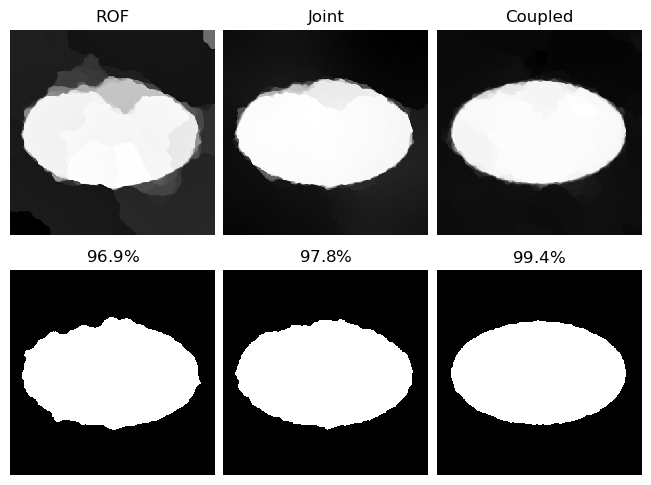

In [19]:
# Display the linear regression, manual ROF and automated ROF estimates
fig, ax = plt.subplots(ncols=3, nrows=2, layout="constrained")

ax[0,0].pcolormesh(h_rof_opt,cmap='gray')
ax[0,0].axis('off');
ax[0,0].set_title('ROF')
ax[0,0].set_box_aspect(1)
ax[1,0].pcolormesh(seg_rof_opt,cmap='gray')
ax[1,0].axis('off');
ax[1,0].set_title("$" + "{:.1f}".format(100*perf_rof) + "$%")
ax[1,0].set_box_aspect(1)

ax[0,1].pcolormesh(h_j_opt,cmap='gray')
ax[0,1].axis('off');
ax[0,1].set_title('Joint')
ax[0,1].set_box_aspect(1)
ax[1,1].pcolormesh(seg_j_opt,cmap='gray')
ax[1,1].axis('off');
ax[1,1].set_title("$" + "{:.1f}".format(100*perf_j) + "$%")
ax[1,1].set_box_aspect(1)

ax[0,2].pcolormesh(h_c_opt,cmap='gray')
ax[0,2].axis('off');
ax[0,2].set_title('Coupled')
ax[0,2].set_box_aspect(1)
ax[1,2].pcolormesh(seg_c_opt,cmap='gray')
ax[1,2].axis('off');
ax[1,2].set_title("$" + "{:.1f}".format(100*perf_c) + "$%")
ax[1,2].set_box_aspect(1)